# Brain Tumor Classification using CNN
### Google Colab Notebook — Fixed & Enhanced Version

In [ ]:
!pip install opendatasets --quiet

import os
import warnings
warnings.filterwarnings('ignore')
import keras
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from PIL import Image
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('dark_background')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import confusion_matrix, classification_report
print('All libraries imported successfully!')


All libraries imported successfully!


# Step 1 — Download Dataset

In [ ]:
import opendatasets as od
od.download('https://www.kaggle.com/datasets/navoneel/brain-mri-images-for-brain-tumor-detection')
print('Dataset downloaded!')


Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: ananyashukla6324
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/navoneel/brain-mri-images-for-brain-tumor-detection


100%|██████████| 15.1M/15.1M [00:00<00:00, 153MB/s]

Dataset downloaded!


# Step 2 — One Hot Encoding the Target Classes

In [ ]:
encoder = OneHotEncoder()
encoder.fit([[0], [1]])
# 0 = Tumor
# 1 = Normal
print('Encoder ready. Classes: 0 = Tumor, 1 = Normal')


Encoder ready. Classes: 0 = Tumor, 1 = Normal


# Step 3 — Load & Preprocess Images

In [ ]:
# Load TUMOR images (label = 0)
data = []
paths = []
result = []

tumor_dir = r'./brain-mri-images-for-brain-tumor-detection/brain_tumor_dataset/yes'
for r, d, f in os.walk(tumor_dir):
    for file in f:
        if file.lower().endswith('.jpg') or file.lower().endswith('.jpeg'):
            paths.append(os.path.join(r, file))

for path in paths:
    img = Image.open(path).convert('RGB')  # ensure RGB
    img = img.resize((128, 128))
    img = np.array(img)
    if img.shape == (128, 128, 3):
        data.append(img)
        result.append(encoder.transform([[0]]).toarray())

print(f'Tumor images loaded: {len(data)}')


Tumor images loaded: 154


In [ ]:
# Load NORMAL images (label = 1)
paths = []
normal_dir = r'./brain-mri-images-for-brain-tumor-detection/brain_tumor_dataset/no'
for r, d, f in os.walk(normal_dir):
    for file in f:
        if file.lower().endswith('.jpg') or file.lower().endswith('.jpeg'):
            paths.append(os.path.join(r, file))

for path in paths:
    img = Image.open(path).convert('RGB')  # ensure RGB
    img = img.resize((128, 128))
    img = np.array(img)
    if img.shape == (128, 128, 3):
        data.append(img)
        result.append(encoder.transform([[1]]).toarray())

print(f'Normal images loaded: {len([x for x in result if np.argmax(x)==1])}')
print(f'Total images: {len(data)}')


Normal images loaded: 97
Total images: 251


In [ ]:
data = np.array(data)
result = np.array(result)
result = result.reshape(result.shape[0], 2)  # dynamic reshape — no hardcoding

print(f'Data shape   : {data.shape}')
print(f'Result shape : {result.shape}')

# Class distribution
tumor_count  = np.sum(result[:, 0] == 1)
normal_count = np.sum(result[:, 1] == 1)
print(f'Tumor samples : {tumor_count}')
print(f'Normal samples: {normal_count}')


Data shape   : (251, 128, 128, 3)
Result shape : (251, 2)
Tumor samples : 154
Normal samples: 97


# Step 4 — Train / Test Split

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(
    data, result, test_size=0.2, shuffle=True, random_state=0
)
print(f'Training samples  : {len(x_train)}')
print(f'Testing  samples  : {len(x_test)}')


Training samples  : 200
Testing  samples  : 51


# Step 5 — Build CNN Model

Architecture: 2× Conv32 → BN → MaxPool → Dropout → 2× Conv64 → BN → MaxPool → Dropout → Dense512 → Softmax(2)

In [ ]:
model = Sequential()

# Block 1
model.add(Conv2D(32, kernel_size=(2,2), activation='relu', input_shape=(128,128,3), padding='Same'))  # Fix: added activation
model.add(Conv2D(32, kernel_size=(2,2), activation='relu', padding='Same'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.25))

# Block 2
model.add(Conv2D(64, kernel_size=(2,2), activation='relu', padding='Same'))
model.add(Conv2D(64, kernel_size=(2,2), activation='relu', padding='Same'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2), strides=(2,2)))
model.add(Dropout(0.25))

# Classifier
model.add(Flatten())
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(2, activation='softmax'))

model.compile(
    loss='categorical_crossentropy',
    optimizer='Adamax',
    metrics=['accuracy']  # Fix: added accuracy metric
)
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 32)   │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 64)     │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 64)     │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 65536)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    33,554,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │         1,026 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,585,602 (128.12 MB)

 Trainable params: 33,585,410 (128.12 MB)

 Non-trainable params: 192 (768.00 B)

# Step 6 — Train the Model

In [ ]:
history = model.fit(
    x_train, y_train,
    epochs=30,
    batch_size=40,
    verbose=1,
    validation_data=(x_test, y_test)
)


Epoch 1/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 22s 4s/step - accuracy: 0.7150 - loss: 23.0314 - val_accuracy: 0.3922 - val_loss: 68.2678
Epoch 2/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 20s 4s/step - accuracy: 0.6950 - loss: 13.8628 - val_accuracy: 0.8039 - val_loss: 9.4583
Epoch 3/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 17s 3s/step - accuracy: 0.7750 - loss: 6.9785 - val_accuracy: 0.8235 - val_loss: 3.9810
Epoch 4/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 20s 4s/step - accuracy: 0.8250 - loss: 3.0040 - val_accuracy: 0.8235 - val_loss: 2.5896
Epoch 5/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 17s 3s/step - accuracy: 0.8100 - loss: 2.5395 - val_accuracy: 0.8431 - val_loss: 2.3959
Epoch 6/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 22s 4s/step - accuracy: 0.8650 - loss: 1.5350 - val_accuracy: 0.8431 - val_loss: 2.5701
Epoch 7/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 19s 3s/step - accuracy: 0.9300 - loss: 0.5958 - val_accuracy: 0.8824 - val_loss: 1.1888
Epoch 8/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 17s 4s/step - accuracy: 0.9350 - loss: 0.4715 - val_accuracy: 0.8824 - val_loss: 0.6233
Epoch

# Step 7 — Training Curves

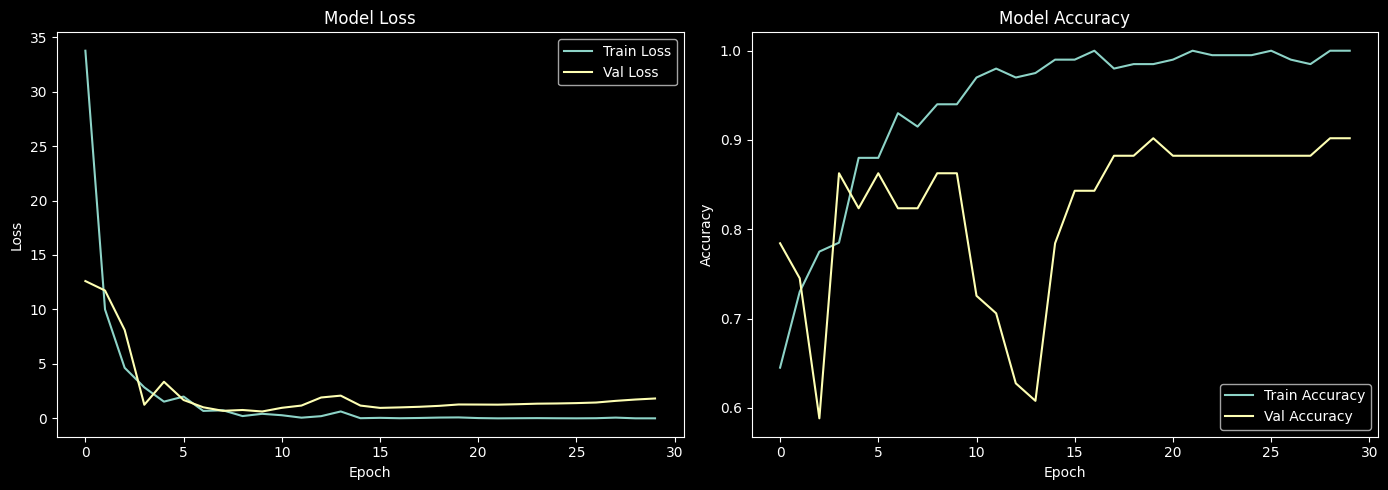

Final Train Accuracy : 100.00%
Final Val Accuracy   : 90.20%


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')  # Fix: was 'Test'
axes[0].set_title('Model Loss')
axes[0].set_ylabel('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend(loc='upper right')

# Accuracy — Fix: was completely missing
axes[1].plot(history.history['accuracy'], label='Train Accuracy')
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[1].set_title('Model Accuracy')
axes[1].set_ylabel('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

print(f"Final Train Accuracy : {history.history['accuracy'][-1]*100:.2f}%")
print(f"Final Val Accuracy   : {history.history['val_accuracy'][-1]*100:.2f}%")


# Step 8 — Model Evaluation

Test Loss     : 1.8234
Test Accuracy : 90.20%
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 405ms/step


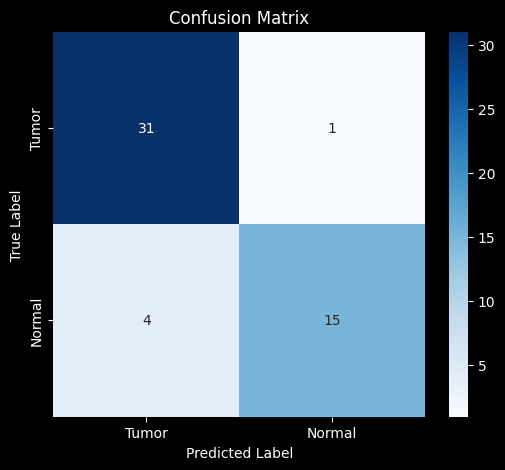

              precision    recall  f1-score   support

       Tumor       0.89      0.97      0.93        32
      Normal       0.94      0.79      0.86        19

    accuracy                           0.90        51
   macro avg       0.91      0.88      0.89        51
weighted avg       0.91      0.90      0.90        51



In [ ]:
loss, accuracy = model.evaluate(x_test, y_test, verbose=0)
print(f'Test Loss     : {loss:.4f}')
print(f'Test Accuracy : {accuracy*100:.2f}%')

# Predictions
y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

# Confusion Matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Tumor', 'Normal'],
            yticklabels=['Tumor', 'Normal'])
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Classification Report
print(classification_report(y_true_classes, y_pred_classes, target_names=['Tumor', 'Normal']))


# Step 9 — Predict on New Images

In [ ]:
def names(number):
    if number == 0:
        return 'Its a Tumor'
    else:
        return 'No, Its not a tumor'

def predict_image(img_path):
    """Predict tumor/normal for any image path."""
    img = Image.open(img_path).convert('RGB')
    x = np.array(img.resize((128, 128)))
    # NOTE: No normalization — matches training data (raw 0-255 pixel values)
    x = x.reshape(1, 128, 128, 3)
    res = model.predict_on_batch(x)
    classification = np.where(res == np.amax(res))[1][0]
    plt.figure(figsize=(4, 4))
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"{res[0][classification]*100:.1f}% — {names(classification)}", fontsize=12)
    plt.show()
    print(f'Result: {names(classification)}')
    print(f'Confidence: {res[0][classification]*100:.2f}%')


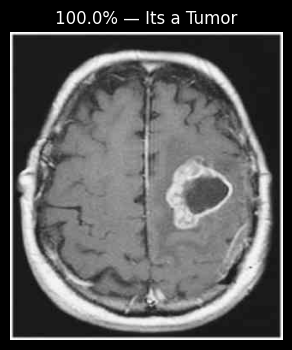

Result: Its a Tumor
Confidence: 100.00%


In [ ]:
# Test on a TUMOR image — dynamically finds file regardless of .jpg/.JPG case
import os
yes_folder = './brain-mri-images-for-brain-tumor-detection/brain_tumor_dataset/yes'
target = 'Y10'
matched = [f for f in os.listdir(yes_folder) if os.path.splitext(f)[0] == target]
if matched:
    predict_image(os.path.join(yes_folder, matched[0]))
else:
    # Fallback: use first available tumor image
    first = [f for f in os.listdir(yes_folder) if f.lower().endswith('.jpg')][0]
    predict_image(os.path.join(yes_folder, first))


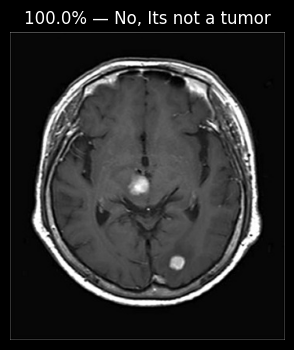

Result: No, Its not a tumor
Confidence: 100.00%


In [ ]:
# Test on a NORMAL image — dynamically finds file regardless of case
no_folder = './brain-mri-images-for-brain-tumor-detection/brain_tumor_dataset/no'
target = 'N17'
matched = [f for f in os.listdir(no_folder) if os.path.splitext(f)[0] == target]
if matched:
    predict_image(os.path.join(no_folder, matched[0]))
else:
    first = [f for f in os.listdir(no_folder) if f.lower().endswith('.jpg')][0]
    predict_image(os.path.join(no_folder, first))


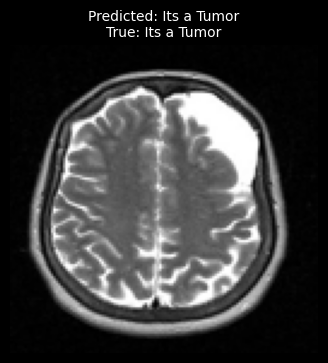

Confidence : 73.94%
Correct    : True


In [ ]:
# Test on a random UNSEEN image from x_test (guaranteed model never saw it)
import random
idx = random.randint(0, len(x_test) - 1)
sample = x_test[idx].reshape(1, 128, 128, 3)
res = model.predict_on_batch(sample)
classification = np.where(res == np.amax(res))[1][0]
true_label = np.argmax(y_test[idx])

plt.figure(figsize=(4, 4))
plt.imshow(x_test[idx].astype('uint8'))
plt.axis('off')
plt.title(f"Predicted: {names(classification)}\nTrue: {names(true_label)}", fontsize=10)
plt.show()
print(f'Confidence : {res[0][classification]*100:.2f}%')
print(f'Correct    : {classification == true_label}')


# Step 10 — Save the Model

In [ ]:
model.save('brain_tumor_model.h5')
print('Model saved as brain_tumor_model.h5')


Model saved as brain_tumor_model.h5


In [ ]:
!pip install flask flask-cors pyngrok -q

In [ ]:
from pyngrok import ngrok
from flask import Flask, request, jsonify
from PIL import Image
import numpy as np
import io
import threading

# ── 1. Set your ngrok auth token ──────────────────────────────────────────────
ngrok.set_auth_token("3EDOsjlSGCnUMSnp9WYft8jb2ry_73TjwUY5iSRPAgbpwBP5S")   # ← replace this

# ── 2. Load your already-trained model ───────────────────────────────────────
# (run this cell AFTER you have trained the model in the same session)
# If you saved it, load it like this:
# from tensorflow import keras
# model = keras.models.load_model('brain_tumor_model.h5')
# Otherwise just use the `model` variable already in memory from training.

# ── 3. Flask app ──────────────────────────────────────────────────────────────
app = Flask(__name__)

HTML = """
<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="UTF-8"/>
<meta name="viewport" content="width=device-width,initial-scale=1.0"/>
<title>Brain Tumor Classifier</title>
<link href="https://fonts.googleapis.com/css2?family=DM+Mono:wght@400;500&family=Syne:wght@700&display=swap" rel="stylesheet"/>
<style>
*,*::before,*::after{box-sizing:border-box;margin:0;padding:0}
:root{
  --bg:#0b0f19;--surface:#111827;--surface2:#1a2234;
  --border:rgba(99,179,237,0.15);--accent:#63b3ed;
  --accent-dim:rgba(99,179,237,0.12);
  --tumor:#fc8181;--normal:#68d391;
  --text:#e2e8f0;--text-muted:#718096;
  --mono:'DM Mono',monospace;--display:'Syne',sans-serif;
}
body{background:var(--bg);color:var(--text);font-family:var(--display);min-height:100vh;display:flex;flex-direction:column;align-items:center}
header{width:100%;max-width:820px;padding:3rem 2rem 0}
.badge{display:inline-flex;align-items:center;gap:6px;font-family:var(--mono);font-size:11px;letter-spacing:.08em;color:var(--accent);border:1px solid var(--border);border-radius:100px;padding:4px 12px;margin-bottom:1rem}
.badge::before{content:'●';font-size:8px}
h1{font-size:clamp(1.8rem,5vw,2.8rem);font-weight:700;letter-spacing:-.02em;line-height:1.1;color:#fff}
h1 span{color:var(--accent)}
.subtitle{margin-top:.75rem;font-size:.9rem;color:var(--text-muted);font-family:var(--mono)}
.divider{width:100%;max-width:820px;height:1px;background:var(--border);margin:2rem 0}
main{width:100%;max-width:820px;padding:0 2rem 4rem;display:flex;flex-direction:column;gap:1.5rem}
.upload-zone{border:1.5px dashed var(--border);border-radius:16px;padding:3rem 2rem;text-align:center;cursor:pointer;transition:border-color .2s,background .2s;position:relative;overflow:hidden}
.upload-zone:hover,.upload-zone.dragover{border-color:var(--accent);background:var(--accent-dim)}
.upload-zone input[type=file]{position:absolute;inset:0;opacity:0;cursor:pointer;width:100%;height:100%}
.upload-icon{width:56px;height:56px;border-radius:12px;background:var(--accent-dim);border:1px solid var(--border);display:flex;align-items:center;justify-content:center;margin:0 auto 1rem}
.upload-icon svg{width:24px;height:24px;stroke:var(--accent);fill:none;stroke-width:1.5}
.upload-title{font-size:1.1rem;font-weight:700;color:#fff;margin-bottom:.4rem}
.upload-hint{font-family:var(--mono);font-size:12px;color:var(--text-muted)}
.grid-2{display:grid;grid-template-columns:1fr 1fr;gap:1.5rem}
@media(max-width:560px){.grid-2{grid-template-columns:1fr}}
.card{background:var(--surface);border:1px solid var(--border);border-radius:16px;padding:1.25rem 1.5rem}
.card-label{font-family:var(--mono);font-size:10px;letter-spacing:.12em;text-transform:uppercase;color:var(--text-muted);margin-bottom:1rem}
#preview-card{display:none}
#preview-card img{width:100%;max-height:260px;object-fit:contain;border-radius:8px;background:#0b0f19}
#result-card{display:none}
.result-verdict{font-size:2rem;font-weight:700;letter-spacing:-.02em;margin-bottom:.25rem}
.result-verdict.tumor{color:var(--tumor)}
.result-verdict.normal{color:var(--normal)}
.result-sub{font-family:var(--mono);font-size:12px;color:var(--text-muted);margin-bottom:1.5rem}
.conf-wrap{margin-bottom:1.25rem}
.conf-label{display:flex;justify-content:space-between;font-family:var(--mono);font-size:11px;color:var(--text-muted);margin-bottom:6px}
.conf-label span:last-child{color:var(--text);font-weight:500}
.bar-bg{height:6px;background:var(--surface2);border-radius:100px;overflow:hidden}
.bar-fill{height:100%;border-radius:100px;transition:width .8s cubic-bezier(.4,0,.2,1)}
.bar-fill.tumor{background:var(--tumor)}
.bar-fill.normal{background:var(--normal)}
.disclaimer{margin-top:1rem;padding:.75rem 1rem;background:rgba(252,129,129,.07);border:1px solid rgba(252,129,129,.2);border-radius:8px;font-family:var(--mono);font-size:11px;color:rgba(252,129,129,.8);line-height:1.6}
.error-box{margin-top:1rem;padding:.75rem 1rem;background:rgba(252,129,129,.07);border:1px solid rgba(252,129,129,.3);border-radius:8px;font-family:var(--mono);font-size:11px;color:var(--tumor)}
.analyze-btn{display:none;width:100%;padding:1rem;background:var(--accent);color:#0b0f19;border:none;border-radius:12px;font-family:var(--display);font-size:1rem;font-weight:700;cursor:pointer;transition:opacity .2s,transform .15s}
.analyze-btn:hover{opacity:.88}
.analyze-btn:active{transform:scale(.98)}
.analyze-btn:disabled{opacity:.4;cursor:not-allowed}
.loading-state{display:none;flex-direction:column;align-items:center;gap:1rem;padding:2rem 0}
.spinner{width:36px;height:36px;border:2px solid var(--border);border-top-color:var(--accent);border-radius:50%;animation:spin .7s linear infinite}
@keyframes spin{to{transform:rotate(360deg)}}
.loading-text{font-family:var(--mono);font-size:12px;color:var(--text-muted)}
.reset-btn{display:none;background:none;border:1px solid var(--border);color:var(--text-muted);font-family:var(--mono);font-size:11px;padding:6px 14px;border-radius:100px;cursor:pointer;transition:border-color .2s,color .2s;margin-top:.75rem}
.reset-btn:hover{border-color:var(--accent);color:var(--accent)}
.arch-section{background:var(--surface);border:1px solid var(--border);border-radius:16px;padding:1.5rem}
.arch-title{font-family:var(--mono);font-size:10px;letter-spacing:.12em;text-transform:uppercase;color:var(--text-muted);margin-bottom:1.25rem}
.arch-flow{display:flex;align-items:center;gap:8px;flex-wrap:wrap}
.arch-node{background:var(--surface2);border:1px solid var(--border);border-radius:8px;padding:5px 12px;font-family:var(--mono);font-size:11px;color:var(--text);white-space:nowrap}
.arch-node.hl{background:var(--accent-dim);border-color:var(--accent);color:var(--accent)}
.arch-arrow{color:var(--text-muted);font-size:14px;flex-shrink:0}
.stats-row{display:grid;grid-template-columns:repeat(3,1fr);gap:1rem;margin-top:1rem}
.stat-box{background:var(--surface2);border-radius:10px;padding:.75rem 1rem;text-align:center}
.stat-num{font-size:1.3rem;font-weight:700;color:var(--accent);font-family:var(--mono)}
.stat-desc{font-family:var(--mono);font-size:10px;color:var(--text-muted);margin-top:2px}
</style>
</head>
<body>
<header>
  <div class="badge">CNN · MRI Classification</div>
  <h1>Brain Tumor<br><span>Classifier</span></h1>
  <p class="subtitle">Convolutional neural network · Binary classification · MRI scans</p>
</header>
<div class="divider"></div>
<main>
  <div class="upload-zone" id="drop-zone">
    <input type="file" id="file-input" accept="image/*"/>
    <div class="upload-icon">
      <svg viewBox="0 0 24 24"><path d="M21 15v4a2 2 0 0 1-2 2H5a2 2 0 0 1-2-2v-4"/><polyline points="17 8 12 3 7 8"/><line x1="12" y1="3" x2="12" y2="15"/></svg>
    </div>
    <div class="upload-title">Drop a brain MRI scan here</div>
    <div class="upload-hint">or click to browse · JPG, PNG, WebP</div>
  </div>

  <div class="grid-2">
    <div class="card" id="preview-card">
      <div class="card-label">MRI preview</div>
      <img id="preview-img" src="" alt="MRI scan"/>
      <button class="reset-btn" id="reset-btn">✕ Clear image</button>
    </div>
    <div class="card" id="result-card">
      <div class="card-label">Classification result</div>
      <div class="loading-state" id="loading-state">
        <div class="spinner"></div>
        <div class="loading-text">Running model inference…</div>
      </div>
      <div id="result-content" style="display:none">
        <div class="result-verdict" id="verdict-text"></div>
        <div class="result-sub" id="result-sub"></div>
        <div class="conf-wrap">
          <div class="conf-label"><span>Tumor probability</span><span id="tumor-pct">—</span></div>
          <div class="bar-bg"><div class="bar-fill tumor" id="tumor-bar" style="width:0%"></div></div>
        </div>
        <div class="conf-wrap">
          <div class="conf-label"><span>Normal probability</span><span id="normal-pct">—</span></div>
          <div class="bar-bg"><div class="bar-fill normal" id="normal-bar" style="width:0%"></div></div>
        </div>
        <div class="disclaimer">⚠ For research purposes only. Not for clinical use.</div>
      </div>
      <div id="error-content" style="display:none">
        <div class="error-box" id="error-msg"></div>
      </div>
    </div>
  </div>

  <button class="analyze-btn" id="analyze-btn">Analyze scan →</button>

  <div class="arch-section">
    <div class="arch-title">Model architecture</div>
    <div class="arch-flow">
      <div class="arch-node hl">Input 128×128×3</div><div class="arch-arrow">→</div>
      <div class="arch-node">Conv2D(32) ×2</div><div class="arch-arrow">→</div>
      <div class="arch-node">BN + Pool</div><div class="arch-arrow">→</div>
      <div class="arch-node">Dropout(0.25)</div><div class="arch-arrow">→</div>
      <div class="arch-node">Conv2D(64) ×2</div><div class="arch-arrow">→</div>
      <div class="arch-node">BN + Pool</div><div class="arch-arrow">→</div>
      <div class="arch-node">Dropout(0.25)</div><div class="arch-arrow">→</div>
      <div class="arch-node">Dense(512)</div><div class="arch-arrow">→</div>
      <div class="arch-node hl">Softmax(2)</div>
    </div>
    <div class="stats-row">
      <div class="stat-box"><div class="stat-num">2</div><div class="stat-desc">Output classes</div></div>
      <div class="stat-box"><div class="stat-num">30</div><div class="stat-desc">Training epochs</div></div>
      <div class="stat-box"><div class="stat-num">80%</div><div class="stat-desc">Train split</div></div>
    </div>
  </div>
</main>

<script>
const dropZone=document.getElementById('drop-zone'),fileInput=document.getElementById('file-input'),
previewCard=document.getElementById('preview-card'),previewImg=document.getElementById('preview-img'),
resultCard=document.getElementById('result-card'),analyzeBtn=document.getElementById('analyze-btn'),
resetBtn=document.getElementById('reset-btn'),loadingState=document.getElementById('loading-state'),
resultContent=document.getElementById('result-content'),errorContent=document.getElementById('error-content'),
errorMsg=document.getElementById('error-msg'),verdictText=document.getElementById('verdict-text'),
resultSub=document.getElementById('result-sub'),tumorPct=document.getElementById('tumor-pct'),
normalPct=document.getElementById('normal-pct'),tumorBar=document.getElementById('tumor-bar'),
normalBar=document.getElementById('normal-bar');
let currentFile=null;
function handleFile(f){
  if(!f||!f.type.startsWith('image/'))return;
  currentFile=f;previewImg.src=URL.createObjectURL(f);
  previewCard.style.display='block';resetBtn.style.display='inline-block';
  analyzeBtn.style.display='block';resultCard.style.display='none';
}
fileInput.addEventListener('change',e=>handleFile(e.target.files[0]));
dropZone.addEventListener('dragover',e=>{e.preventDefault();dropZone.classList.add('dragover')});
dropZone.addEventListener('dragleave',()=>dropZone.classList.remove('dragover'));
dropZone.addEventListener('drop',e=>{e.preventDefault();dropZone.classList.remove('dragover');handleFile(e.dataTransfer.files[0])});
analyzeBtn.addEventListener('click',async()=>{
  if(!currentFile)return;
  analyzeBtn.disabled=true;resultCard.style.display='block';
  loadingState.style.display='flex';resultContent.style.display='none';errorContent.style.display='none';
  try{
    const fd=new FormData();fd.append('file',currentFile);
    const res=await fetch('/predict',{method:'POST',body:fd});
    const data=await res.json();
    loadingState.style.display='none';
    if(data.error){errorMsg.textContent='⚠ '+data.error;errorContent.style.display='block';}
    else{
      const isTumor=data.label==='Tumor';
      verdictText.textContent=isTumor?'Tumor detected':'No tumor found';
      verdictText.className='result-verdict '+(isTumor?'tumor':'normal');
      resultSub.textContent='Confidence: '+data.confidence+'% · class='+(isTumor?'0 (Tumor)':'1 (Normal)');
      tumorPct.textContent=data.tumor_prob+'%';normalPct.textContent=data.normal_prob+'%';
      requestAnimationFrame(()=>{tumorBar.style.width=data.tumor_prob+'%';normalBar.style.width=data.normal_prob+'%'});
      resultContent.style.display='block';
    }
  }catch(e){
    loadingState.style.display='none';
    errorMsg.textContent='⚠ Could not reach server.';errorContent.style.display='block';
  }
  analyzeBtn.disabled=false;
});
resetBtn.addEventListener('click',()=>{
  previewCard.style.display='none';resultCard.style.display='none';
  analyzeBtn.style.display='none';resetBtn.style.display='none';
  fileInput.value='';currentFile=null;
});
</script>
</body>
</html>
"""

@app.route('/')
def index():
    return HTML

@app.route('/predict', methods=['POST'])
def predict():
    if 'file' not in request.files:
        return jsonify({'error': 'No file uploaded'}), 400
    file = request.files['file']
    try:
        img_bytes = file.read()
        img = Image.open(io.BytesIO(img_bytes)).convert('RGB')
        img = img.resize((128, 128))
        arr = np.array(img).reshape(1, 128, 128, 3)

        preds       = model.predict(arr, verbose=0)
        tumor_prob  = float(preds[0][0])
        normal_prob = float(preds[0][1])
        label       = 'Tumor' if tumor_prob > normal_prob else 'Normal'
        confidence  = round(max(tumor_prob, normal_prob) * 100, 2)

        return jsonify({
            'label':       label,
            'confidence':  confidence,
            'tumor_prob':  round(tumor_prob  * 100, 2),
            'normal_prob': round(normal_prob * 100, 2),
        })
    except Exception as e:
        return jsonify({'error': str(e)}), 500

# ── 4. Start Flask in background thread + open ngrok tunnel ──────────────────
threading.Thread(target=lambda: app.run(port=5000, use_reloader=False)).start()

public_url = ngrok.connect(5000).public_url
print("=" * 55)
print(f"  ✅  App is live at: {public_url}")
print("=" * 55)
print("  Open the link above in your browser to use the app.")

 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:5000
INFO:werkzeug:Press CTRL+C to quit


  ✅  App is live at: https://opponent-symphony-cloud.ngrok-free.dev
  Open the link above in your browser to use the app.
